# Exercício prático sobre RBF

## Definição da RBF

In [1]:
import numpy as np

class RBFNeuron:
    def __init__(self, input_size, sigma):
        random_gen = np.random.default_rng()
        self.center = random_gen.uniform(0, 1, size=(input_size,1))
        self.center = self.center/np.linalg.norm(self.center) #center must have norm equal to 1
        self.sigma = sigma

    def output(self, x):
        x_diff_center_n  = np.linalg.norm(x-self.center)
        return np.exp( - (x_diff_center_n**2)/ (2*self.sigma**2))


class RBFNeuralNetwork:
    def __init__(self, n_inputs, n_neurons, n_outputs, sigma, output_fcn, d_output_fcn):
        self.n_inputs = n_inputs
        self.n_neurons = n_neurons + 1 # to include bias neuron
        self.n_outputs = n_outputs
        self.output_fcn = output_fcn
        self.output_fcn_map = np.vectorize(self.output_fcn)
        self.d_output_fcn = d_output_fcn
        self.d_output_fcn_map = np.vectorize(self.d_output_fcn)
        self.neurons = []
        self.neurons_output = np.zeros( (self.n_neurons, 1) )
        self.network_v = np.zeros((n_outputs,1))
        self.network_output = np.zeros( (n_outputs, 1) )
        for i in range(self.n_neurons -1 ): #individual neuron initialization, except bias neuron
            self.neurons.append(RBFNeuron(n_inputs, sigma))
        
        self.weights = np.random.randn(n_outputs, self.n_neurons ) #output matrix initialization
    def output(self, x):
        for i in range(self.n_neurons):
            if i < ( self.n_neurons - 1) :
                self.neurons_output[i,0] = self.neurons[i].output(x)
            else:
                self.neurons_output[i,0] = 1 #bias neuron
        self.network_v = self.weights @ self.neurons_output
        self.network_output = self.output_fcn_map(self.network_v)
        return self.network_output

    def learn(self, x, y_d, eta):
        y_e = self.output(x)
        e = y_d - y_e
        #delta = e * self.d_output_fcn_map(self.network_v) #for mse
        delta = e # for cross-entropy
        self.weights = self.weights + eta *  (delta  @ self.neurons_output.T)
        return e

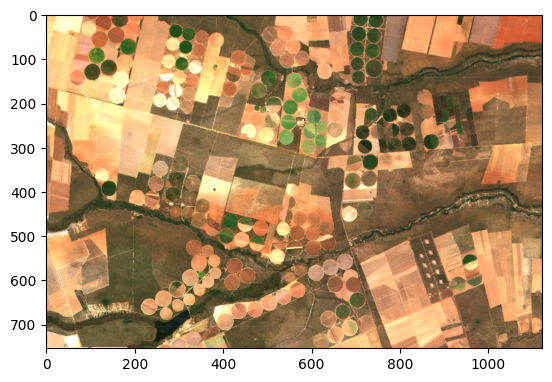

In [1]:
from matplotlib import image 
from PIL import Image 
from matplotlib import pyplot as plt
import numpy as np
from random import shuffle


# First let`s load and examine the entire image:
# Area of interest divisa entre o Tocantins e Bahia BBOX (-45.8670,-11.9768,-45.4059,-11.7157).
# Pivôs de irrigação são sistemas automatizados, compostos por torres metálicas sobre rodas,
# que giram em torno de um ponto central para distribuir água e fertilizantes de forma uniforme e controlada.
data_path = "./data_detect_rbf/"
file_name = "sentinel-2_tocantins_20200828.bmp"
full_img = Image.open(data_path + file_name).convert("RGB")
plt.imshow(full_img)

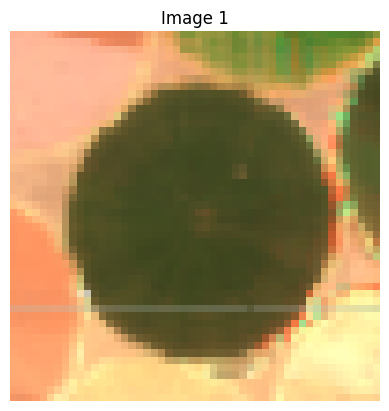

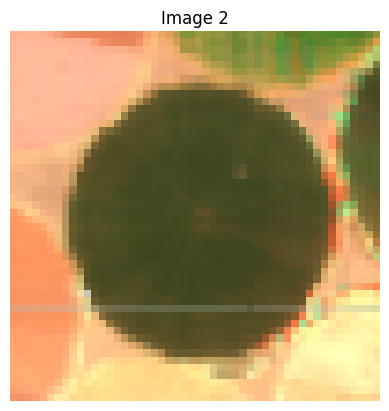

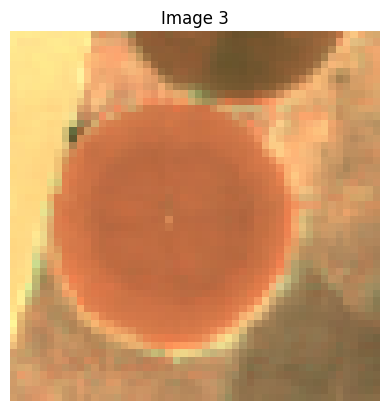

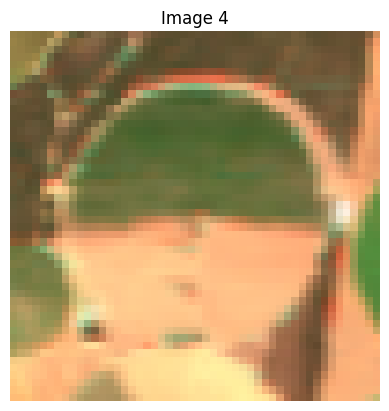

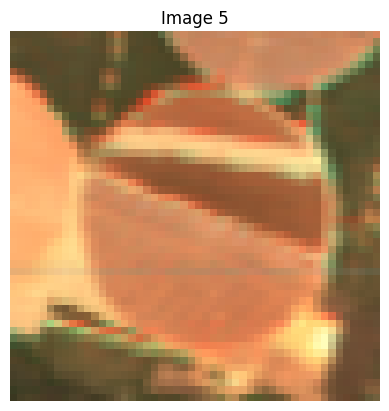

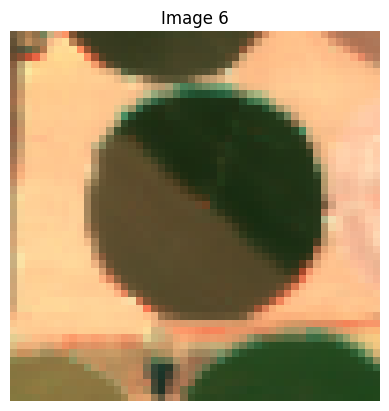

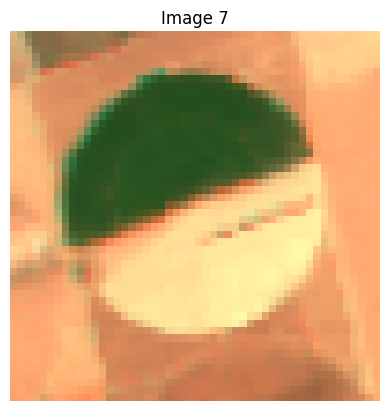

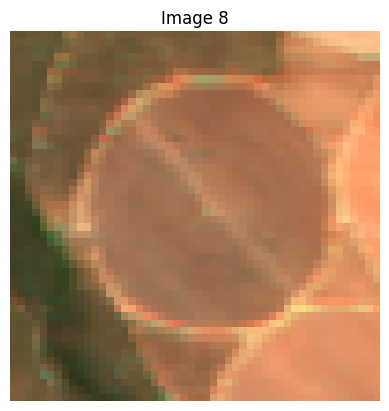

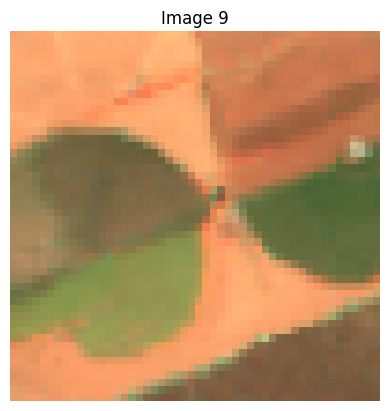

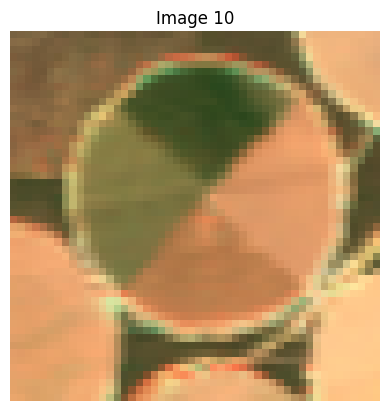

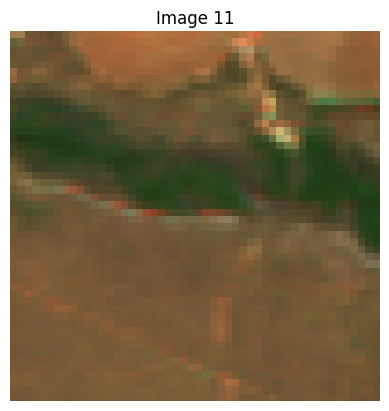

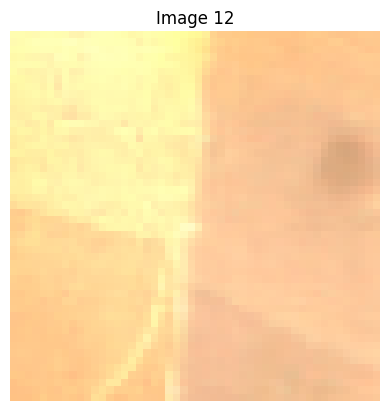

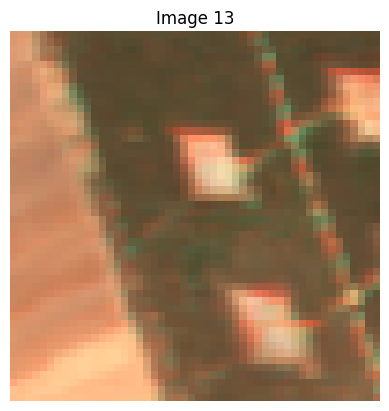

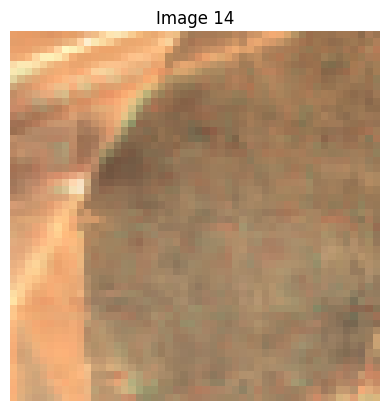

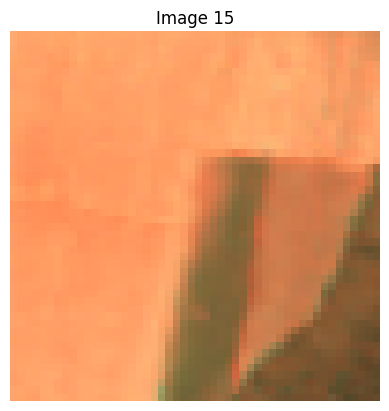

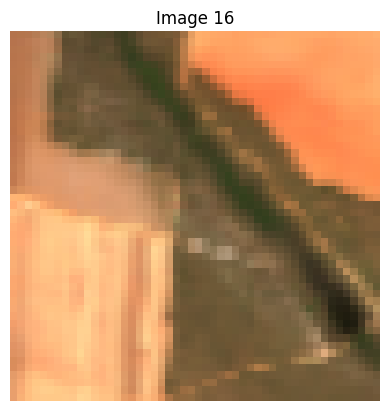

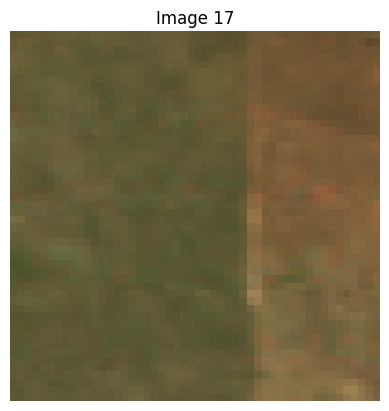

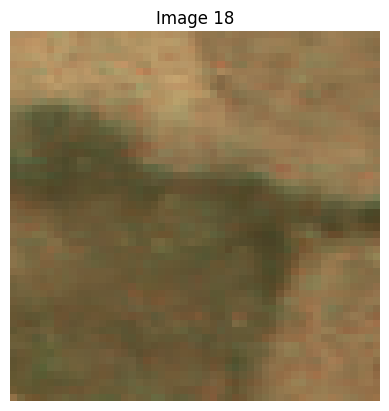

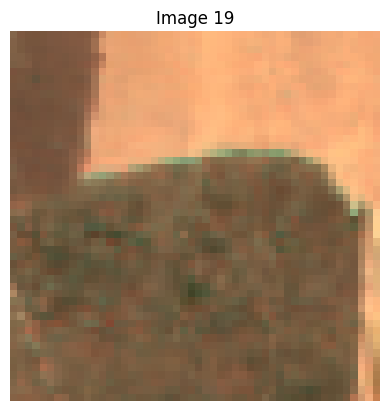

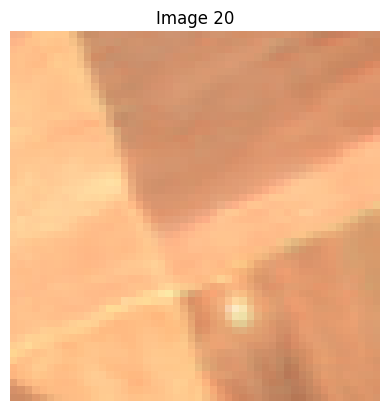

In [55]:
# Now we load each example
# First we open our training image (dimensions WxH) 
img_w = 50
img_h = 50

pos = "positive_example_{}.bmp"
neg = "negative_example_{}.bmp"

n_samples = 20

imgs_files = []

for i in range(n_samples):
    if i <= 9:
        img_file = pos.format(i)
    else:
        img_file = neg.format(i)
    imgs_files.append(img_file)
    
training_dataset_size = len(imgs_files)
imgs = []

for img_name in imgs_files:
    imgs.append(Image.open(data_path + img_name).convert("RGB").resize((img_w, img_h)))

for i, img in enumerate(imgs):
    plt.imshow(img)
    plt.title(f"Image {i + 1}")
    plt.axis("off")  # axis removal
    plt.show()

In [56]:
# Now we flatten each image:
x = np.array([ np.array(img).flatten()/np.linalg.norm(np.array(img).flatten()) for img in imgs]) 
y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
y = y.reshape(-1,1)
print(x.shape)
print(y.shape)
print("Number of examples: ", x.shape[0])
print("Number of features: ", x.shape[1])
print(x[0])
print(len(x[0]))

(20, 7500)
(20, 1)
Number of examples:  20
Number of features:  7500
[0.01996684 0.01404781 0.01144344 ... 0.02012468 0.01657326 0.01136452]
7500


In [19]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 27.0 MB/s  0:00:00 23.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 50.4 MB/s  0:00:004.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]


In [57]:
# We use k-means to estimate centers for each neuron
from sklearn.cluster import KMeans
from itertools import combinations

n_neurons = 10
kmeans = KMeans(n_clusters=n_neurons, random_state=0)
kmeans.fit(x)
centers = kmeans.cluster_centers_
centers /= np.linalg.norm(centers, axis=1, keepdims=True)

dists = [np.linalg.norm(c1 - c2) for c1,c2 in combinations(centers, 2)]
sigma = np.mean(dists)

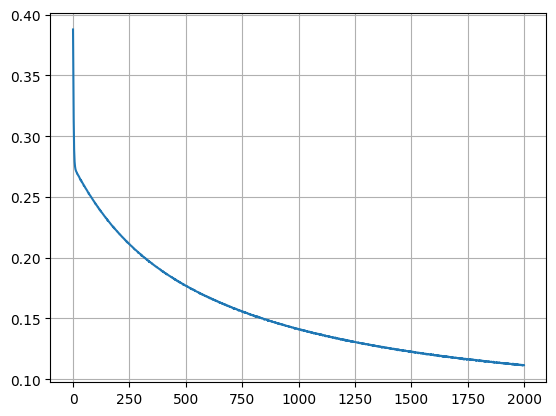

In [58]:
# Now we build and train our RBF neural network:
from random import shuffle

np.random.seed(666)

def fcn(x):
    return (1/(1+np.exp(-x)))

def d_fcn(x):
    return  fcn(x)*(1-fcn(x))
    
#sigma = 0.5* np.sqrt(x.shape[1]) # to avoid the curse of dimensionality
rbf_neural_network = RBFNeuralNetwork(x.shape[1], 10, 1, sigma, fcn, d_fcn)

# set centers using k-means, based on input feature vector
for i in range(rbf_neural_network.n_neurons -1):
    rbf_neural_network.neurons[i].center = centers[i].reshape(-1,1)
    
n_epochs = 2000
eta = 0.01 
indices = list( range(x.shape[0]) )
mse = []

for i in range(n_epochs):
    shuffle(indices)
    squared_error = []
    for k in indices:
        y_d = y[k]
        x_in = x[k]
        x_in = x_in.reshape(-1,1)
        e = rbf_neural_network.learn(x_in, y_d, eta)
        squared_error.append(e**2)
    mse.append( np.mean(squared_error) )

plt.plot(mse)
plt.grid()
plt.show()

In [59]:
# now we try to classify each patch along the entire image
window_step = 4
patch_size = 50
img = np.array(full_img)
rows, columns, _ = img.shape
print(rows, columns, _)
results = []

for i in range(0, rows - patch_size + 1, window_step):
    for j in range(0, columns - patch_size + 1, window_step):
        patch = img[i:i + patch_size, j:j + patch_size]
        x = patch.flatten().reshape(-1, 1)  # patch vectorization
        x = x/np.linalg.norm(x) # patch normalization
        
        y_e = rbf_neural_network.output(x)
        if y_e > 0.80:
            results.append((i, j, 1)) # pivo detected
        else:
            results.append((i, j, 0)) # pivo not detected

754 1122 3


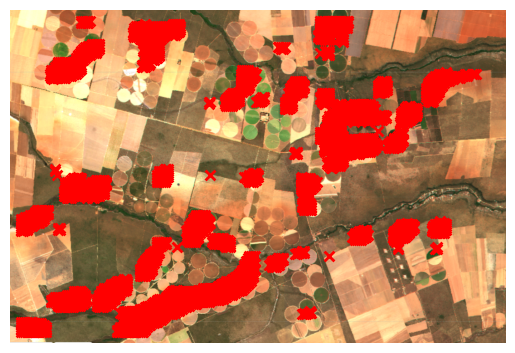

In [60]:
plt.imshow(full_img)
plt.axis("off")

for (i, j, c) in results:
    if c == 1:
        # centro do patch
        y_center = i + patch_size // 2
        x_center = j + patch_size // 2
        plt.scatter(x_center, y_center, marker='x', s=50, c= 'red', linewidths = 2)

plt.show()

### Aumentando a taxa de aprendizagem

In [61]:
# Now we flatten each image:
x = np.array([ np.array(img).flatten()/np.linalg.norm(np.array(img).flatten()) for img in imgs]) 
y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
y = y.reshape(-1,1)
print(x.shape)
print(y.shape)
print("Number of examples: ", x.shape[0])
print("Number of features: ", x.shape[1])
print(x[0])
print(len(x[0]))

(20, 7500)
(20, 1)
Number of examples:  20
Number of features:  7500
[0.01996684 0.01404781 0.01144344 ... 0.02012468 0.01657326 0.01136452]
7500


In [62]:
# We use k-means to estimate centers for each neuron
from sklearn.cluster import KMeans
from itertools import combinations

n_neurons = 10
kmeans = KMeans(n_clusters=n_neurons, random_state=0)
kmeans.fit(x)
centers = kmeans.cluster_centers_
centers /= np.linalg.norm(centers, axis=1, keepdims=True)

dists = [np.linalg.norm(c1 - c2) for c1,c2 in combinations(centers, 2)]
sigma = np.mean(dists)

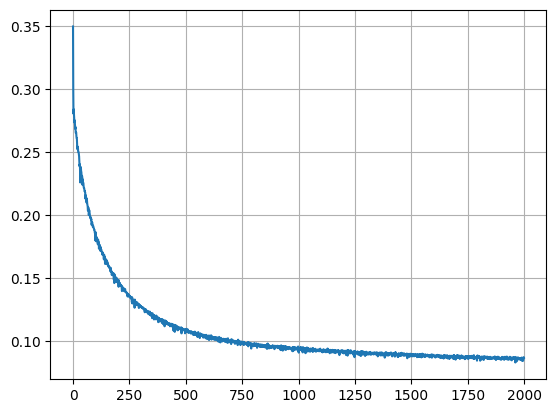

In [63]:
# Now we build and train our RBF neural network:
from random import shuffle

np.random.seed(666)

def fcn(x):
    return (1/(1+np.exp(-x)))

def d_fcn(x):
    return  fcn(x)*(1-fcn(x))
    
#sigma = 0.5* np.sqrt(x.shape[1]) # to avoid the curse of dimensionality
rbf_neural_network = RBFNeuralNetwork(x.shape[1], 10, 1, sigma, fcn, d_fcn)

# set centers using k-means, based on input feature vector
for i in range(rbf_neural_network.n_neurons -1):
    rbf_neural_network.neurons[i].center = centers[i].reshape(-1,1)
    
n_epochs = 2000
eta = 0.05
indices = list( range(x.shape[0]) )
mse = []

for i in range(n_epochs):
    shuffle(indices)
    squared_error = []
    for k in indices:
        y_d = y[k]
        x_in = x[k]
        x_in = x_in.reshape(-1,1)
        e = rbf_neural_network.learn(x_in, y_d, eta)
        squared_error.append(e**2)
    mse.append( np.mean(squared_error) )

plt.plot(mse)
plt.grid()
plt.show()

In [66]:
# now we try to classify each patch along the entire image
window_step = 4
patch_size = 50
img = np.array(full_img)
rows, columns, _ = img.shape
print(rows, columns, _)
results = []

for i in range(0, rows - patch_size + 1, window_step):
    for j in range(0, columns - patch_size + 1, window_step):
        patch = img[i:i + patch_size, j:j + patch_size]
        x = patch.flatten().reshape(-1, 1)  # patch vectorization
        x = x/np.linalg.norm(x) # patch normalization
        
        y_e = rbf_neural_network.output(x)
        if y_e > 0.90:
            results.append((i, j, 1)) # pivo detected
        else:
            results.append((i, j, 0)) # pivo not detected

754 1122 3


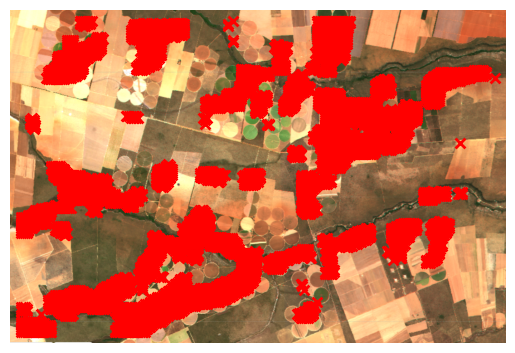

In [67]:
plt.imshow(full_img)
plt.axis("off")

for (i, j, c) in results:
    if c == 1:
        # centro do patch
        y_center = i + patch_size // 2
        x_center = j + patch_size // 2
        plt.scatter(x_center, y_center, marker='x', s=50, c= 'red', linewidths = 2)

plt.show()